In [1]:
using CairoMakie
using FITSIO
using Glob
using HDF5
using Printf

In [2]:
colwidth_pt = 242.26653
colwidth_px = 4/3 * colwidth_pt

323.02203999999995

In [3]:
ncbvs = Dict()
times = Dict()
for q in 1:17
    for file in glob(joinpath(@__DIR__, "..", "lc-files", "HLSP", @sprintf("Q%02d", q), "detrended_signif_threshold", "hlsp*.fits"))
        f = FITS(file, "r")
        nc = read_key(f[1], "NCBV")
        ncbvs[q] = nc[1]

        t = read(f[2], "TIME")
        times[q] = t
        
        break
    end
end

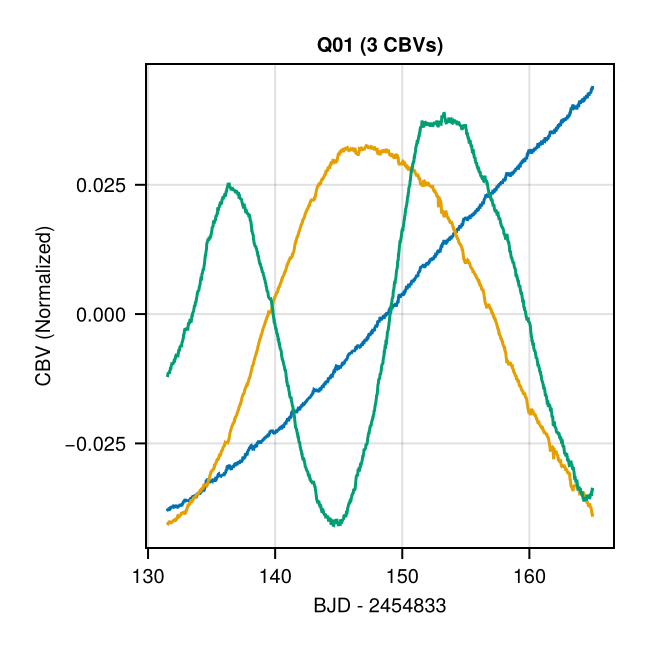

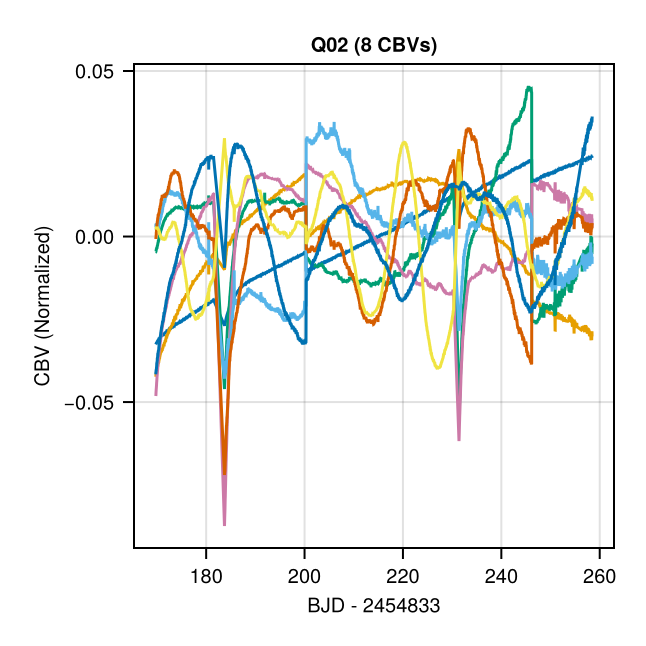

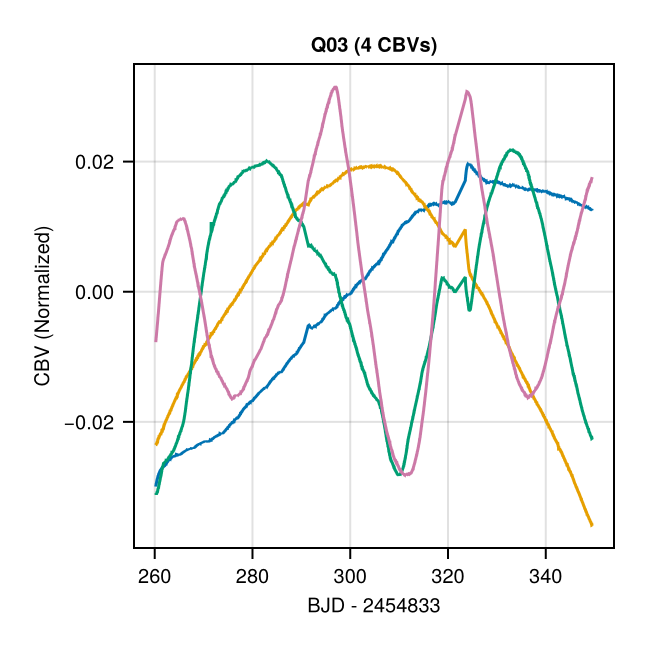

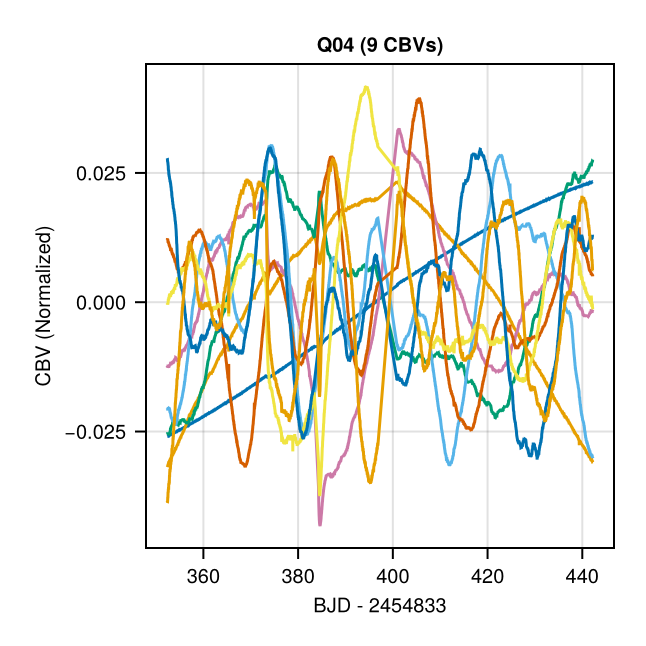

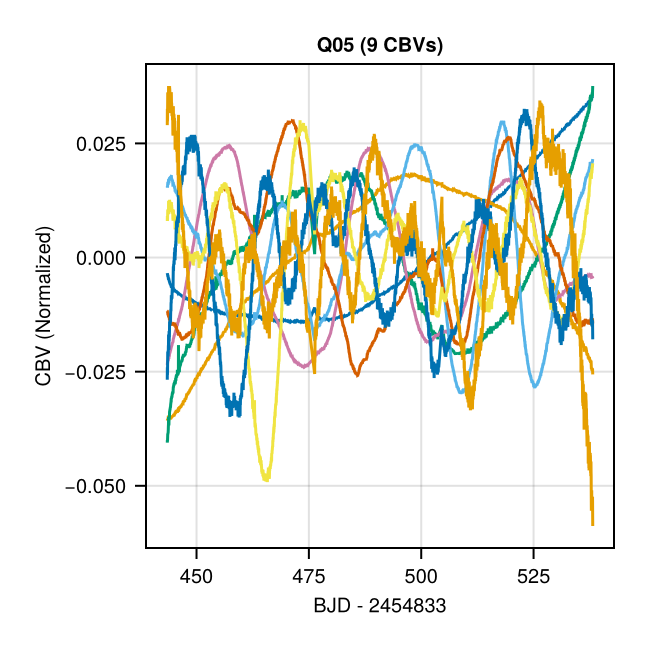

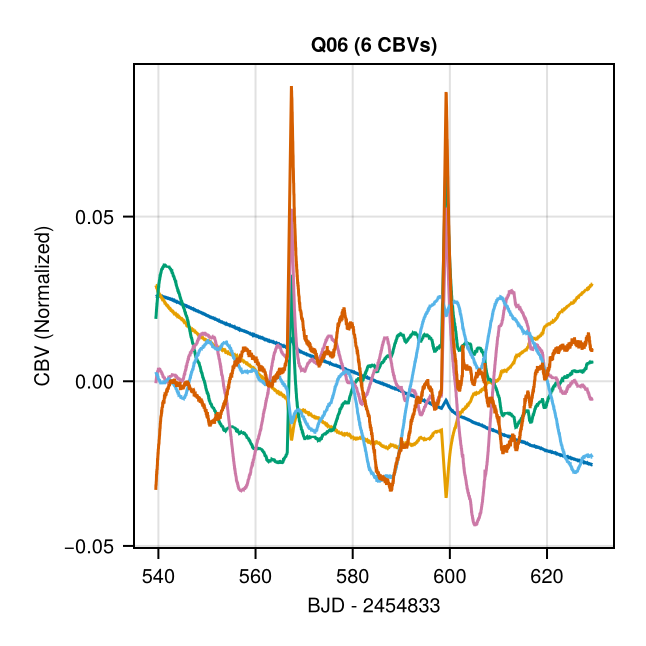

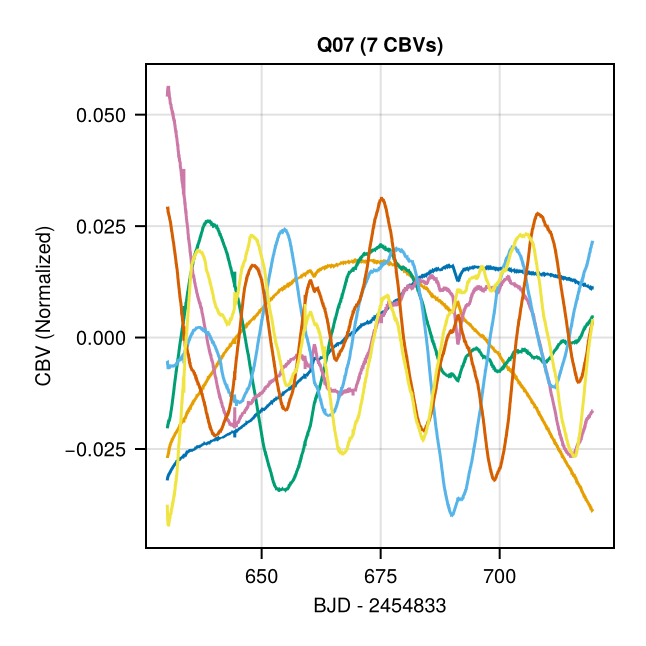

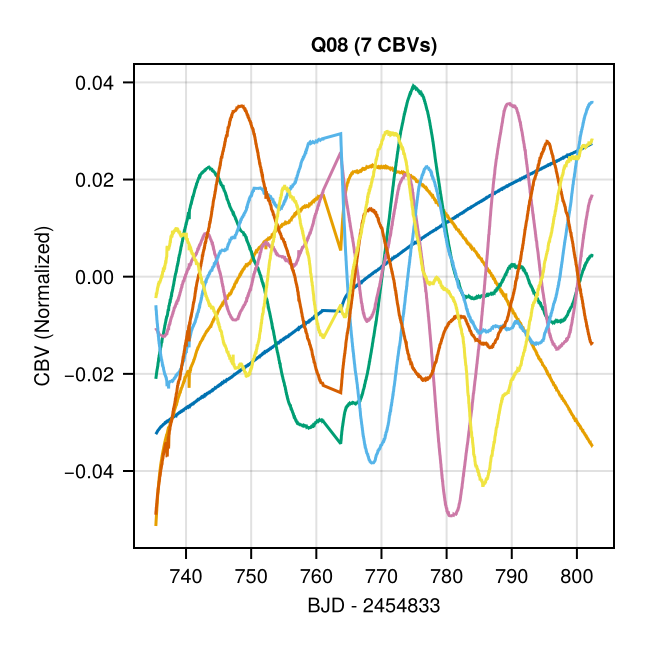

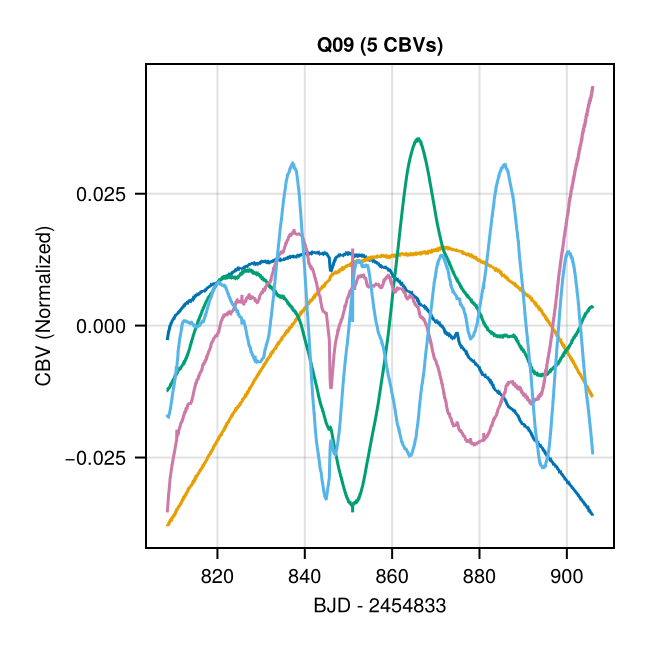

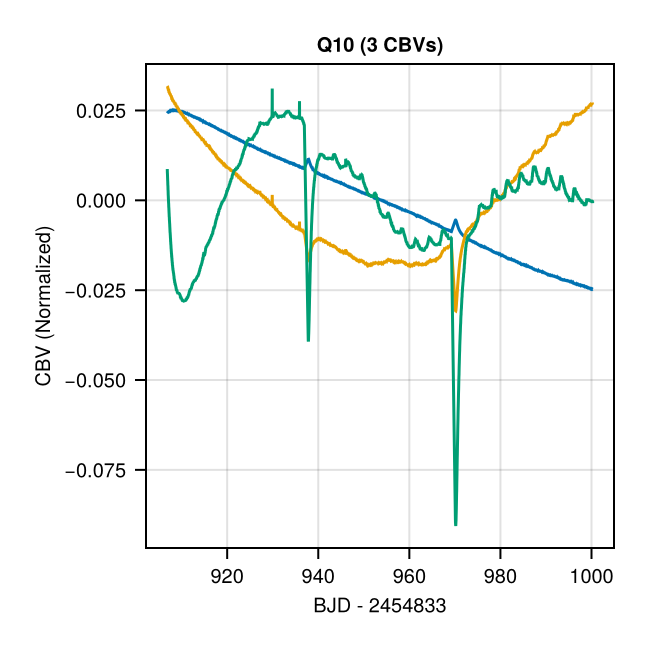

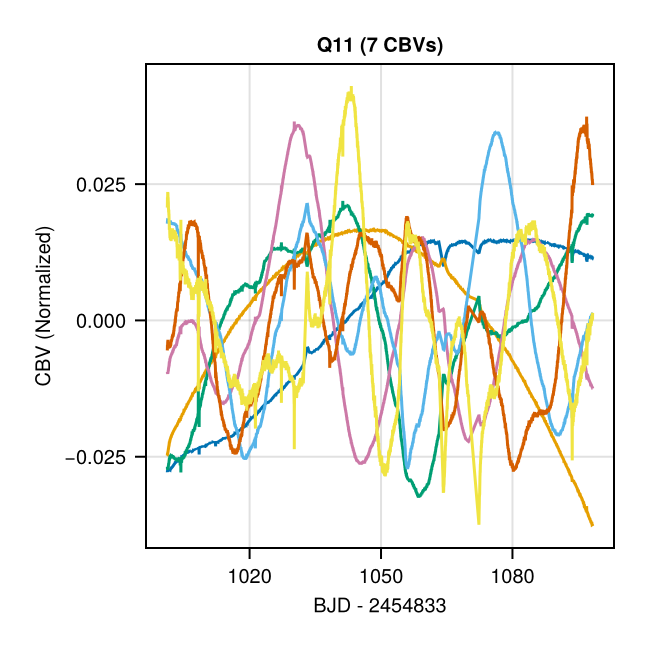

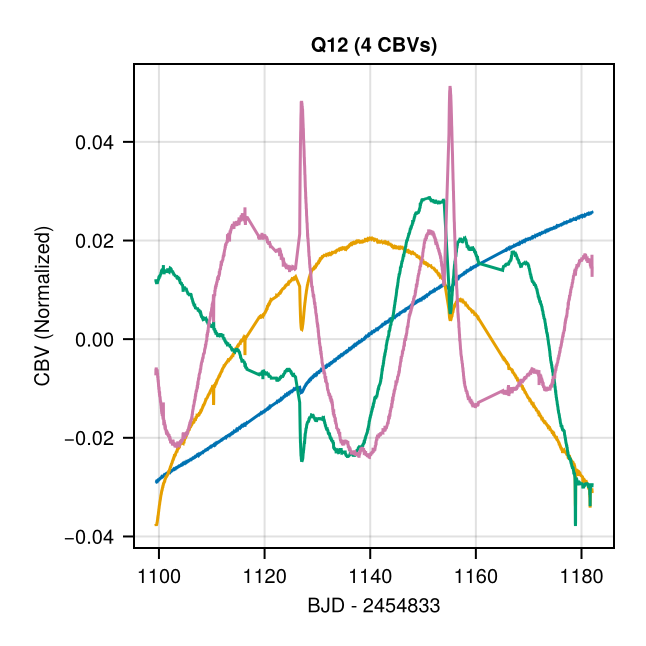

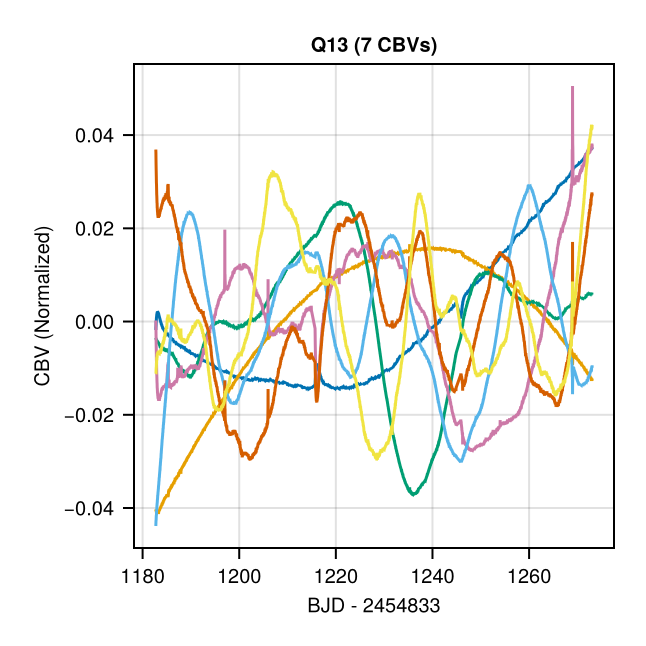

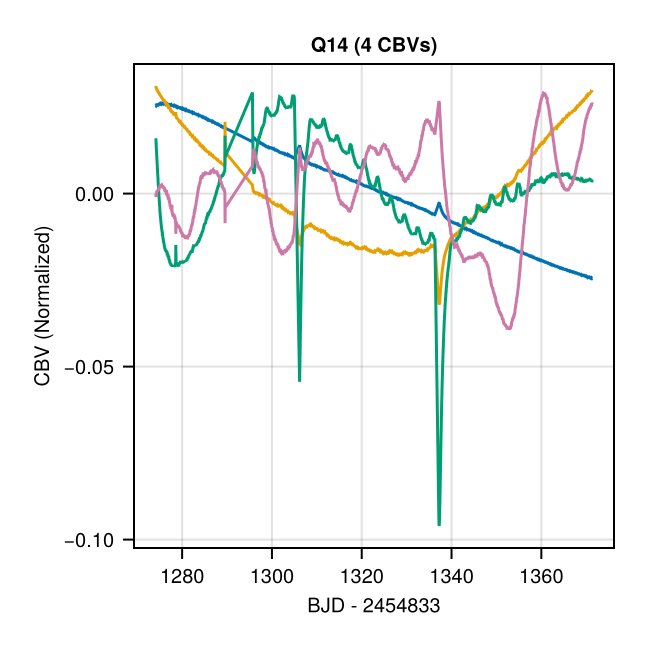

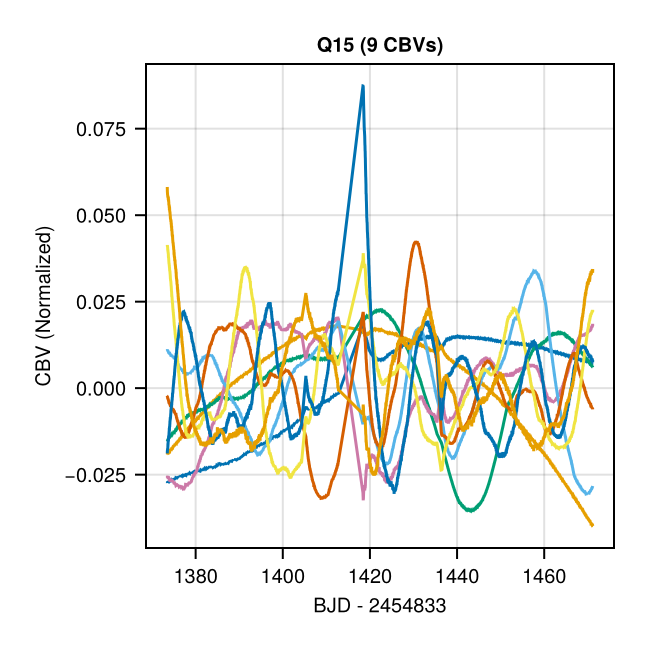

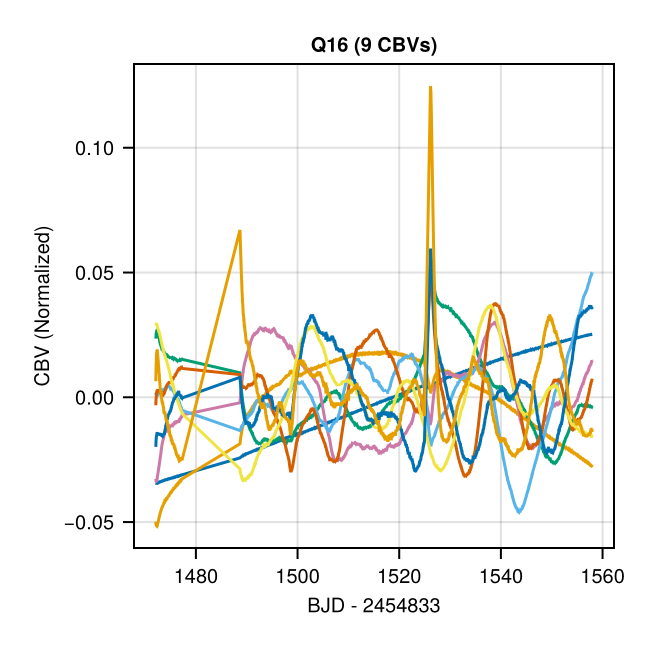

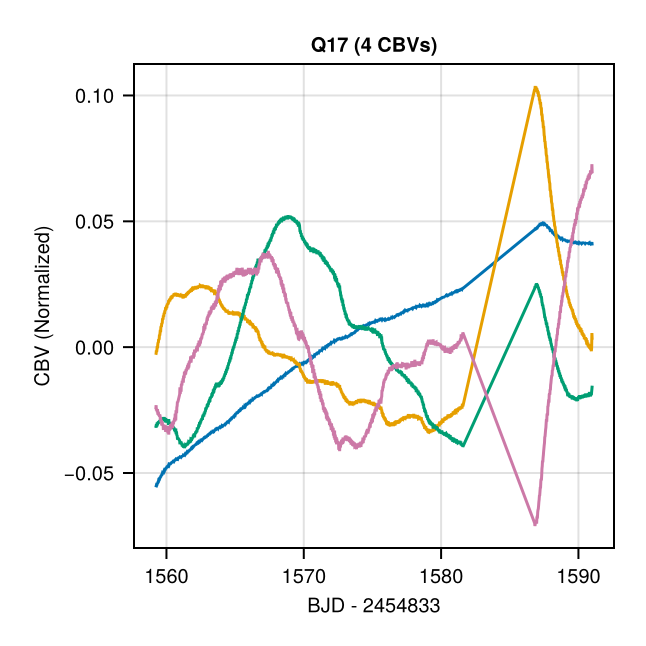

In [ ]:
for q in 1:17
    haskey(ncbvs, q) || continue

    cbvs = h5open(joinpath(@__DIR__, "..", "lc-files", "HLSP", "CBV", @sprintf("Q%02d.h5", q)), "r") do file
        read(file, "basis")
    end

    nc = ncbvs[q]

    f = Figure(size=(colwidth_px, colwidth_px), fontsize=10)
    ax = Axis(f[1, 1], title=@sprintf("Q%02d (%d CBVs)", q, nc), xlabel="BJD - 2454833", ylabel="CBV (Normalized)")
    for i in 1:nc
        lines!(ax, times[q], cbvs[:, i])
    end

    save(joinpath(@__DIR__, "..", "figures", @sprintf("Q%02d_CBV.pdf", q)), f)
    display(f)
end